# Notebook 03 — Preprocess CogAge Composite

**Purpose:** Fix folder structures, parse, resample, window and save  
the CogAge Composite dataset in unified per-stream format.

**Dataset characteristics:**
- 8 subjects → remove Subject 7 (no watch) and Subject 8 (idle states) → **6 subjects**
- 7 composite activities (multi-minute continuous recordings)
- 10 sensor streams: Phone×7, Watch×2, Glasses×1
- Keep LEFT HAND only — delete right, both, mixed folders
- Sliding window T=250, stride=125 (50% overlap) applied to each recording
- Frequencies inferred from file timestamps (not documented)

**Per-subject structure differences:**
```
Subj 1,3,5,6 : SubjX/Training/Lefthand/   SubjX/Testing/Lefthand/   ← clean
Subj 2       : SubjX/Lefthand/             ← no train/test split, chronological 70/30
Subj 4       : SubjX/Training/left/        ← rename left→lefthand, delete both+right
```

**Input root:**
```
/content/drive/MyDrive/sensory_data/sensory_data/
```

**Output** (saved to `PROCESSED_PATHS['cogage_composite']/`):
```
phone_accel.npy           (N, 250, 3)
phone_barometer.npy       (N, 250, 3)
phone_gravity.npy         (N, 250, 3)
phone_gyro.npy            (N, 250, 3)
phone_linear_accel.npy    (N, 250, 3)
phone_magnetometer.npy    (N, 250, 3)
phone_orientation.npy     (N, 250, 3)
watch_accel.npy           (N, 250, 3)
watch_gyro.npy            (N, 250, 3)
jins_accel.npy            (N, 250, 3)
y.npy                     (N,)
subject_ids.npy           (N,)
stream_names.json
split_info.json
normalizers/
```

---
**⚠ Read Cell 2 carefully before running — it explains the structure fix logic.**  
**Run notebook 00 before this notebook.**

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

print('\n✅ Setup complete')
print(f'   Dataset : CogAge Composite')
print(f'   Root    : {RAW_PATHS["cogage_composite"]["root"]}')
print(f'   Output  : {PROCESSED_PATHS["cogage_composite"]}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subje

## Cell 2 — Dataset Config and Sensor Map

**Sensor file naming in CogAge Composite:**
- Phone sensors  → `PhoneAccelerometer.csv`, `PhoneGyroscope.csv`, etc.
- Watch sensors  → `android.sensor.accelerometer.csv`, `android.sensor.gyroscope.csv`
- JINS glasses   → `JinsSensor.csv` (tab-separated, many columns — keep only accel X,Y,Z)

**⚠ If the file names in your data differ slightly from the above,**  
**update `SENSOR_FILE_MAP` below to match exactly what you see.**  
Run `os.listdir()` on one activity folder to check.

In [ ]:
cfg  = DATASET_CONFIGS['cogage_composite']
root = RAW_PATHS['cogage_composite']['root']

# ─── Subjects ─────────────────────────────────────────────────────────────────
# Remove subjects 7 (no watch data) and 8 (idle states)
VALID_SUBJECTS = [1, 2, 3, 4, 5, 6]

# ─── Activities ───────────────────────────────────────────────────────────────
# Folder names as they appear on disk → integer label
ACTIVITY_FOLDER_MAP = {
    'brushing_teeth'        : 0,
    'cleaning_room'         : 1,
    'handling_medications'  : 2,
    'preparing_food'        : 3,
    'styling hair'          : 4,   # note: space not underscore in original
    'using_telephone'       : 5,
    'washing_hands'         : 6,
}

# ─── Sensor file map ──────────────────────────────────────────────────────────
# Format: 'filename_without_extension' → (stream_name, is_jins)
# Frequencies are inferred from timestamps in Cell 4
# is_jins=True → tab-separated, multi-column, keep only accel X,Y,Z
# is_jins=False → standard CSV with timestamp + x + y + z columns
#
# ⚠ UPDATE THESE NAMES if your files differ — check with os.listdir() in Cell 3
SENSOR_FILE_MAP = {
    # Phone sensors (7)
    'PhoneAccelerometer'         : ('phone_accel',          False),
    'PhoneGravity'               : ('phone_gravity',        False),
    'PhoneGyroscope'             : ('phone_gyro',           False),
    'PhoneLinearAccelerometer'   : ('phone_linear_accel',   False),
    'PhoneMagnetometer'          : ('phone_magnetometer',   False),
    'PhoneOrientation'           : ('phone_orientation',    False),
    # Watch sensors (2)
    'android.sensor.accelerometer': ('watch_accel',         False),
    'android.sensor.gyroscope'    : ('watch_gyro',          False),
    # JINS glasses (1) — special parsing
    'JinsSensor'                  : ('jins_accel',          True),
}

STREAM_NAMES = [v[0] for v in SENSOR_FILE_MAP.values()]
IS_JINS      = {v[0]: v[1] for v in SENSOR_FILE_MAP.values()}

print('✅ Config set')
print(f'   Valid subjects  : {VALID_SUBJECTS}')
print(f'   Activities      : {list(ACTIVITY_FOLDER_MAP.keys())}')
print(f'   Sensor streams  : {STREAM_NAMES}')
print(f'\n   ⚠ If sensor file names differ from the map above,')
print(f'     run Cell 3 first to inspect actual file names,')
print(f'     then update SENSOR_FILE_MAP before continuing.')

✅ Config set
   Valid subjects  : [1, 2, 3, 4, 5, 6]
   Activities      : ['brushing_teeth', 'cleaning_room', 'handling_medications', 'preparing_food', 'styling hair', 'using_telephone', 'washing_hands']
   Sensor streams  : ['phone_accel', 'phone_gravity', 'phone_gyro', 'phone_linear_accel', 'phone_magnetometer', 'phone_orientation', 'watch_accel', 'watch_gyro', 'jins_accel']

   ⚠ If sensor file names differ from the map above,
     run Cell 3 first to inspect actual file names,
     then update SENSOR_FILE_MAP before continuing.


## Cell 3 — Inspect Folder Structure

Run this cell to see exactly what folders and files exist.  
Use this to verify subject folder names, activity folder names,  
and sensor file names before the main processing loop.

In [ ]:
print(f'Root contents: {root}')
print()

top_level = sorted(os.listdir(root))
print(f'Top-level folders: {top_level}')
print()

# Inspect structure of each subject folder
for subj_id in VALID_SUBJECTS:
    # Try common subject folder name patterns
    for pattern in [f'Subj{subj_id}', f'subj{subj_id}',
                    f'Subject{subj_id}', f'subject{subj_id}',
                    f'Sub{subj_id}', f'S{subj_id}']:
        subj_path = os.path.join(root, pattern)
        if os.path.isdir(subj_path):
            contents = sorted(os.listdir(subj_path))
            print(f'  {pattern}/  →  {contents}')
            # Go one level deeper for first subfolder
            for sub in contents[:3]:
                sub_path = os.path.join(subj_path, sub)
                if os.path.isdir(sub_path):
                    sub_contents = sorted(os.listdir(sub_path))
                    print(f'    {sub}/  →  {sub_contents[:5]}')
                    # Go one more level to see activity folders or files
                    for act in sub_contents[:2]:
                        act_path = os.path.join(sub_path, act)
                        if os.path.isdir(act_path):
                            act_files = sorted(os.listdir(act_path))
                            print(f'      {act}/  →  {act_files[:6]}')
                            # Show one activity folder's files
                            for af in act_files[:1]:
                                af_path = os.path.join(act_path, af)
                                if os.path.isdir(af_path):
                                    print(f'        {af}/  →  {sorted(os.listdir(af_path))[:8]}')
            break
    print()

Root contents: /content/drive/MyDrive/sensory_data/

Top-level folders: ['ReadMe.txt', 'Subj1', 'Subj2', 'Subj3', 'Subj4', 'Subj5', 'Subj6', 'Subj7', 'Subj8']

  Subj1/  →  ['testing', 'training']
    testing/  →  ['lefthand', 'righthand']
      lefthand/  →  ['brushing_teeth_composite_activity2018_03_17_14_29_42', 'brushing_teeth_composite_activity2018_03_17_14_40_18', 'brushing_teeth_composite_activity2018_03_19_17_41_57', 'brushing_teeth_composite_activity2018_03_19_17_55_38', 'brushing_teeth_composite_activity2018_03_20_01_22_03', 'brushing_teeth_composite_activity2018_03_20_01_37_48']
        brushing_teeth_composite_activity2018_03_17_14_29_42/  →  ['JinsSensor.csv', 'PhoneAccelerometer.csv', 'PhoneBarometer.csv', 'PhoneGravity.csv', 'PhoneGyroscope.csv', 'PhoneLinearAccelerometer.csv', 'PhoneMagnetometer.csv', 'PhoneOrientation.csv']
      righthand/  →  ['brushing_teeth_composite_activity2018_03_21_13_22_15', 'brushing_teeth_composite_activity2018_03_21_13_32_47', 'brushing_tee

## Cell 4 — Frequency Inference Utility

Frequencies are not documented for CogAge Composite.  
We infer them from the median inter-sample timestamp gap in each file.

In [ ]:
def infer_frequency_from_timestamps(timestamps: np.ndarray) -> float:
    """
    Infer sampling frequency from a sequence of timestamps (milliseconds).
    Uses median inter-sample gap to be robust to missing samples.

    Args:
        timestamps : (T,) array of timestamps in milliseconds

    Returns:
        Estimated frequency in Hz. Returns TARGET_FREQ if cannot be determined.
    """
    if len(timestamps) < 2:
        return float(TARGET_FREQ)

    diffs = np.diff(timestamps.astype(np.float64))
    # Remove zero or negative diffs (clock resets or duplicates)
    diffs = diffs[diffs > 0]

    if len(diffs) == 0:
        return float(TARGET_FREQ)

    median_gap_ms = np.median(diffs)
    if median_gap_ms <= 0:
        return float(TARGET_FREQ)

    freq = 1000.0 / median_gap_ms   # ms → Hz

    # Clamp to reasonable range [1, 500] Hz
    freq = np.clip(freq, 1.0, 500.0)
    return float(freq)


print('✅ Frequency inference utility defined')
print('   Frequencies will be inferred per-file from median timestamp gap')

✅ Frequency inference utility defined
   Frequencies will be inferred per-file from median timestamp gap


## Cell 5 — Sensor File Parsers

Two parsers:
1. **Standard CSV parser** — for phone and watch sensors  
   Format: `timestamp, x, y, z` (comma or tab separated)
2. **JINS parser** — tab-separated, many columns, keep only `Accelerometer_X/Y/Z`

In [ ]:
def parse_standard_sensor_csv(
    filepath: str
) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """
    Parse a standard phone/watch sensor CSV file.

    Handles:
    - Comma separated: timestamp,x,y,z
    - Tab separated:   timestamp\tx\ty\tz
    - With or without header row

    Returns:
        (timestamps, xyz) where:
            timestamps : (T,) int64 array in milliseconds
            xyz        : (T, 3) float32 array
        or None if file is empty/corrupt
    """
    try:
        # Try pandas read with automatic separator detection
        # sep=None with engine='python' auto-detects delimiter
        df = pd.read_csv(
            filepath,
            sep=None,
            engine='python',
            header=None,
            on_bad_lines='skip',
        )
    except Exception:
        return None

    if df is None or len(df) < 2:
        return None

    # Drop header row if first row contains non-numeric values
    try:
        pd.to_numeric(df.iloc[0, 0])
    except (ValueError, TypeError):
        df = df.iloc[1:].reset_index(drop=True)

    if len(df) < 2:
        return None

    # We need at least 4 columns: timestamp, x, y, z
    if df.shape[1] < 4:
        return None

    try:
        timestamps = pd.to_numeric(df.iloc[:, 0], errors='coerce').values.astype(np.int64)
        x          = pd.to_numeric(df.iloc[:, 1], errors='coerce').values
        y          = pd.to_numeric(df.iloc[:, 2], errors='coerce').values
        z          = pd.to_numeric(df.iloc[:, 3], errors='coerce').values
    except Exception:
        return None

    # Drop rows with NaN
    valid = ~(np.isnan(x) | np.isnan(y) | np.isnan(z))
    if valid.sum() < 2:
        return None

    xyz = np.stack([x[valid], y[valid], z[valid]], axis=1).astype(np.float32)
    ts  = timestamps[valid]

    return ts, xyz


def parse_jins_sensor_csv(
    filepath: str
) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """
    Parse the JINS sensor file (JinsSensor.csv).

    JINS format (tab-separated, with header):
    Timestamp  Accelerometer_X  Accelerometer_Y  Accelerometer_Z  Roll  Pitch  Yaw  ...

    We keep ONLY Accelerometer_X, Y, Z — discard all other columns.

    Returns:
        (timestamps, xyz) or None
    """
    try:
        df = pd.read_csv(
            filepath,
            sep=None,
            engine='python',
            on_bad_lines='skip',
        )
    except Exception:
        return None

    if df is None or len(df) < 2:
        return None

    # Normalise column names
    df.columns = [str(c).strip() for c in df.columns]

    # Find timestamp column
    ts_col = None
    for col in df.columns:
        if col.lower() in ('timestamp', 'time', 'ts'):
            ts_col = col
            break
    if ts_col is None:
        ts_col = df.columns[0]   # fallback: first column

    # Find accelerometer columns
    # Try standard names first, then positional fallback
    accel_cols = []
    for candidate in [
        ['Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z'],
        ['AccelerometerX',  'AccelerometerY',  'AccelerometerZ'],
        ['accel_x',         'accel_y',         'accel_z'],
    ]:
        if all(c in df.columns for c in candidate):
            accel_cols = candidate
            break

    if not accel_cols:
        # Positional fallback: use columns 1, 2, 3
        if df.shape[1] >= 4:
            accel_cols = [df.columns[1], df.columns[2], df.columns[3]]
        else:
            return None

    try:
        timestamps = pd.to_numeric(df[ts_col], errors='coerce').values.astype(np.int64)
        x = pd.to_numeric(df[accel_cols[0]], errors='coerce').values
        y = pd.to_numeric(df[accel_cols[1]], errors='coerce').values
        z = pd.to_numeric(df[accel_cols[2]], errors='coerce').values
    except Exception:
        return None

    valid = ~(np.isnan(x) | np.isnan(y) | np.isnan(z))
    if valid.sum() < 2:
        return None

    xyz = np.stack([x[valid], y[valid], z[valid]], axis=1).astype(np.float32)
    ts  = timestamps[valid]

    return ts, xyz


def parse_sensor_file(
    filepath   : str,
    is_jins    : bool
) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """Dispatch to the correct parser based on sensor type."""
    if is_jins:
        return parse_jins_sensor_csv(filepath)
    else:
        return parse_standard_sensor_csv(filepath)


print('✅ Sensor file parsers defined')

✅ Sensor file parsers defined


## Cell 6 — Subject Path Resolver

Each subject has a different folder structure.  
This cell maps each subject to a list of  
`(activity_folder_path, activity_label, split)` tuples.

In [ ]:
def find_subject_folder(root: str, subj_id: int) -> Optional[str]:
    """
    Find the subject folder for a given subject ID.
    Tries multiple common naming patterns.
    """
    for pattern in [f'Subj{subj_id}', f'subj{subj_id}',
                    f'Subject{subj_id}', f'subject{subj_id}',
                    f'Sub{subj_id}', f'S{subj_id}']:
        path = os.path.join(root, pattern)
        if os.path.isdir(path):
            return path
    return None


def find_activity_folders(
    lefthand_dir : str
) -> List[Tuple[str, int]]:
    """
    Scan a lefthand directory for activity recording folders.
    Each activity recording folder name starts with the activity name
    followed by a timestamp: e.g. brushing_teeth_composite_activity2018_...

    Returns list of (folder_path, activity_label) tuples.
    """
    results = []
    if not os.path.isdir(lefthand_dir):
        return results

    for folder_name in sorted(os.listdir(lefthand_dir)):
        folder_path = os.path.join(lefthand_dir, folder_name)
        if not os.path.isdir(folder_path):
            continue

        # Match folder name to activity
        matched_label = None
        for act_name, label in ACTIVITY_FOLDER_MAP.items():
            # Folder name should start with activity name (may have spaces/underscores)
            folder_lower = folder_name.lower().replace(' ', '_')
            act_lower    = act_name.lower().replace(' ', '_')
            if folder_lower.startswith(act_lower):
                matched_label = label
                break

        if matched_label is not None:
            results.append((folder_path, matched_label, folder_name))

    return results


def get_recording_folders_for_subject(
    root     : str,
    subj_id  : int
) -> List[Dict]:
    """
    Return all recording folders for one subject with their metadata.

    Handles the three structural variants:
    - Subjects 1,3,5,6 : Training/Lefthand + Testing/Lefthand
    - Subject 2        : Lefthand/ (no session split → chronological 70/30)
    - Subject 4        : Training/left + Testing/left (renamed to lefthand)

    Returns list of dicts:
        folder_path, activity_label, split ('train'|'test'), subject_id
    """
    subj_path = find_subject_folder(root, subj_id)
    if subj_path is None:
        print(f'   ⚠ Subject {subj_id}: folder not found in {root}')
        return []

    results = []
    top_contents = [d for d in os.listdir(subj_path)
                    if os.path.isdir(os.path.join(subj_path, d))]

    # ── Subjects 1, 3, 5, 6: Training/Lefthand + Testing/Lefthand ────────────
    # Also handles Subject 4 Training/left after rename
    train_dirs  = []
    test_dirs   = []
    lefthand_only_dirs = []  # Subject 2 case

    for d in top_contents:
        d_lower = d.lower()
        d_path  = os.path.join(subj_path, d)

        if d_lower in ('training', 'train'):
            # Look for lefthand subfolder
            for lh_name in ['Lefthand', 'lefthand', 'left', 'Left']:
                lh_path = os.path.join(d_path, lh_name)
                if os.path.isdir(lh_path):
                    train_dirs.append(lh_path)
                    break
            else:
                # No lefthand subfolder — treat training dir directly
                train_dirs.append(d_path)

        elif d_lower in ('testing', 'test'):
            for lh_name in ['Lefthand', 'lefthand', 'left']:
                lh_path = os.path.join(d_path, lh_name)
                if os.path.isdir(lh_path):
                    test_dirs.append(lh_path)
                    break
            else:
                test_dirs.append(d_path)

        elif d_lower in ('lefthand', 'left'):
            # Subject 2: Lefthand/ directly under subject folder
            lefthand_only_dirs.append(d_path)

        elif d_lower in ('righthand', 'right', 'both', 'mixed'):
            # Skip right hand, both, mixed
            continue

    # ── Process train/test split cases ────────────────────────────────────────
    for lh_dir in train_dirs:
        for folder_path, label, fname in find_activity_folders(lh_dir):
            results.append({
                'folder_path'    : folder_path,
                'activity_label' : label,
                'split'          : 'train',
                'subject_id'     : subj_id,
                'folder_name'    : fname,
            })

    for lh_dir in test_dirs:
        for folder_path, label, fname in find_activity_folders(lh_dir):
            results.append({
                'folder_path'    : folder_path,
                'activity_label' : label,
                'split'          : 'test',
                'subject_id'     : subj_id,
                'folder_name'    : fname,
            })

    # ── Subject 2: chronological 70/30 split ──────────────────────────────────
    for lh_dir in lefthand_only_dirs:
        all_recordings = find_activity_folders(lh_dir)

        # Group by activity, sort each group chronologically by folder name
        # (folder name contains timestamp: activity_name...2018_03_17_14_29_42)
        by_activity: Dict[int, list] = defaultdict(list)
        for folder_path, label, fname in all_recordings:
            by_activity[label].append((folder_path, label, fname))

        for label, recs in by_activity.items():
            # Sort by folder name (timestamp is embedded, lexicographic sort works)
            recs_sorted = sorted(recs, key=lambda x: x[2])
            n_train     = max(1, int(round(len(recs_sorted) * 0.70)))

            for i, (folder_path, lab, fname) in enumerate(recs_sorted):
                split = 'train' if i < n_train else 'test'
                results.append({
                    'folder_path'    : folder_path,
                    'activity_label' : lab,
                    'split'          : split,
                    'subject_id'     : subj_id,
                    'folder_name'    : fname,
                })

    return results


# ─── Scan all valid subjects ───────────────────────────────────────────────────
print('Scanning all valid subject folders...\n')

all_recordings = []
for subj_id in VALID_SUBJECTS:
    recs = get_recording_folders_for_subject(root, subj_id)
    all_recordings.extend(recs)
    train_count = sum(1 for r in recs if r['split'] == 'train')
    test_count  = sum(1 for r in recs if r['split'] == 'test')
    acts_found  = set(r['activity_label'] for r in recs)
    print(f'   Subject {subj_id}: {len(recs):>3} recordings | '
          f'train={train_count} test={test_count} | '
          f'activities={sorted(acts_found)}')

print(f'\n   Total recordings to process: {len(all_recordings)}')
print(f'\n✅ Folder scan complete')
print(f'   If any subject shows 0 recordings, check the subject folder name pattern')
print(f'   and update find_subject_folder() accordingly.')

Scanning all valid subject folders...

   Subject 1: 140 recordings | train=70 test=70 | activities=[0, 1, 2, 3, 4, 5, 6]
   Subject 2:  97 recordings | train=69 test=28 | activities=[0, 1, 2, 3, 4, 5, 6]
   Subject 3:  94 recordings | train=47 test=47 | activities=[0, 1, 2, 3, 4, 5, 6]
   Subject 4:  20 recordings | train=20 test=0 | activities=[0, 1, 2, 5]
   Subject 5:  98 recordings | train=49 test=49 | activities=[0, 1, 2, 3, 4, 5, 6]
   Subject 6:  83 recordings | train=42 test=41 | activities=[0, 1, 2, 3, 4, 5, 6]

   Total recordings to process: 532

✅ Folder scan complete
   If any subject shows 0 recordings, check the subject folder name pattern
   and update find_subject_folder() accordingly.


## Cell 7 — Inspect One Recording Folder

Check what files are actually inside one recording folder.  
Use this to verify sensor file names match `SENSOR_FILE_MAP`.

In [ ]:
if all_recordings:
    sample_rec  = all_recordings[0]
    sample_path = sample_rec['folder_path']
    files       = sorted(os.listdir(sample_path))

    print(f'Sample recording folder:')
    print(f'  Path     : {sample_path}')
    print(f'  Subject  : {sample_rec["subject_id"]}')
    print(f'  Activity : {cfg["activity_labels"][sample_rec["activity_label"]]}')
    print(f'  Split    : {sample_rec["split"]}')
    print(f'  Files ({len(files)}):')
    for f in files:
        fpath    = os.path.join(sample_path, f)
        size_kb  = os.path.getsize(fpath) / 1000 if os.path.isfile(fpath) else 0
        in_map   = any(f.startswith(k) or f == k + '.csv' for k in SENSOR_FILE_MAP)
        status   = '✅' if in_map else '❓'
        print(f'    {status} {f:<50} ({size_kb:.1f} KB)')

    print()
    print('  ❓ = file not matched in SENSOR_FILE_MAP')
    print('  If you see ❓ for sensor files you want to use,')
    print('  update SENSOR_FILE_MAP in Cell 2 with the exact filename.')
else:
    print('⚠ No recordings found — check root path and subject folder names.')

Sample recording folder:
  Path     : /content/drive/MyDrive/sensory_data/Subj1/training/lefthand/brushing_teeth_composite_activity2018_03_17_14_48_18
  Subject  : 1
  Activity : brushing_teeth
  Split    : train
  Files (11):
    ✅ JinsSensor.csv                                     (235.4 KB)
    ✅ PhoneAccelerometer.csv                             (1852.7 KB)
    ❓ PhoneBarometer.csv                                 (148.5 KB)
    ✅ PhoneGravity.csv                                   (1848.0 KB)
    ✅ PhoneGyroscope.csv                                 (2065.4 KB)
    ✅ PhoneLinearAccelerometer.csv                       (2002.7 KB)
    ✅ PhoneMagnetometer.csv                              (915.7 KB)
    ✅ PhoneOrientation.csv                               (1817.3 KB)
    ✅ android.sensor.accelerometer.csv                   (1301.0 KB)
    ✅ android.sensor.gyroscope.csv                       (1380.6 KB)
    ❓ preferences.txt                                    (0.0 KB)

  ❓ = file not matc

## Cell 8 — Main Processing Loop

For each recording folder:
1. Load all 10 sensor files
2. Infer native frequency from timestamps
3. Resample to 50Hz
4. Apply sliding window (T=250, stride=125)
5. Store all windows with label and subject ID

If any sensor file is missing from a recording → skip that recording entirely.

In [ ]:
# ─── Accumulators ─────────────────────────────────────────────────────────────
stream_windows : Dict[str, list] = {s: [] for s in STREAM_NAMES}
all_labels      = []
all_subject_ids = []
all_splits      = []

n_windows_total = 0
n_recs_skipped  = 0
skip_log        = []

# Track inferred frequencies for reporting
freq_log: Dict[str, list] = {s: [] for s in STREAM_NAMES}

print(f'Processing {len(all_recordings)} recording folders...')
print(f'Window: {WINDOW_SIZE} samples | Stride: {WINDOW_STRIDE} | Min windows needed: 1')
print()

for rec in all_recordings:
    folder_path   = rec['folder_path']
    label         = rec['activity_label']
    subj_id       = rec['subject_id']
    split         = rec['split']

    # ── Load and resample all streams ─────────────────────────────────────────
    resampled_streams = {}
    skip_reason       = None

    for file_prefix, (stream_name, is_jins) in SENSOR_FILE_MAP.items():
        # Try with and without .csv extension
        fpath = None
        for fname in [f'{file_prefix}.csv', f'{file_prefix}.CSV',
                      f'{file_prefix}.txt', file_prefix]:
            candidate = os.path.join(folder_path, fname)
            if os.path.isfile(candidate):
                fpath = candidate
                break

        if fpath is None:
            skip_reason = f'missing file: {file_prefix}'
            break

        parsed = parse_sensor_file(fpath, is_jins)
        if parsed is None:
            skip_reason = f'parse failed: {file_prefix}'
            break

        timestamps, xyz = parsed

        # Infer native frequency
        native_freq = infer_frequency_from_timestamps(timestamps)
        freq_log[stream_name].append(native_freq)

        # Resample to TARGET_FREQ
        resampled = resample_stream(xyz, src_freq=native_freq)

        if len(resampled) < WINDOW_SIZE:
            skip_reason = (
                f'{file_prefix}: too short after resample '
                f'({len(resampled)} < {WINDOW_SIZE})'
            )
            break

        resampled_streams[stream_name] = resampled

    if skip_reason is not None:
        n_recs_skipped += 1
        if len(skip_log) < 50:
            skip_log.append({
                'subject'  : subj_id,
                'activity' : cfg['activity_labels'][label],
                'split'    : split,
                'reason'   : skip_reason,
            })
        continue

    # ── Trim all streams to same length ───────────────────────────────────────
    min_len = min(len(v) for v in resampled_streams.values())
    for sn in resampled_streams:
        resampled_streams[sn] = resampled_streams[sn][:min_len]

    # ── Apply sliding window using reference stream ────────────────────────────
    ref_stream = resampled_streams[STREAM_NAMES[0]]
    ref_wins, labs, subs = sliding_window(
        ref_stream, label=label, subject_id=subj_id
    )

    if len(ref_wins) == 0:
        n_recs_skipped += 1
        continue

    n_wins = len(ref_wins)

    # Extract matching windows from all other streams
    starts = list(range(0, min_len - WINDOW_SIZE + 1, WINDOW_STRIDE))
    for stream_name in STREAM_NAMES:
        arr  = resampled_streams[stream_name]
        wins = np.stack([arr[s:s + WINDOW_SIZE] for s in starts], axis=0)
        stream_windows[stream_name].append(wins)

    all_labels.extend([label] * n_wins)
    all_subject_ids.extend([subj_id] * n_wins)
    all_splits.extend([split] * n_wins)
    n_windows_total += n_wins

print(f'── Results ──')
print(f'   Total windows     : {n_windows_total:,}')
print(f'   Recordings skipped: {n_recs_skipped}')

if skip_log:
    print(f'\n   Skip log (first {min(10, len(skip_log))}):')
    for e in skip_log[:10]:
        print(f'     S{e["subject"]} | {e["activity"]:<25} | {e["split"]} | {e["reason"]}')

# ─── Frequency report ─────────────────────────────────────────────────────────
print(f'\n── Inferred frequencies (median across recordings) ──')
for stream_name, freqs in freq_log.items():
    if freqs:
        print(f'   {stream_name:<22} → median={np.median(freqs):.1f}Hz '
              f'min={np.min(freqs):.1f} max={np.max(freqs):.1f}')

print(f'\n✅ Main loop complete')

Processing 532 recording folders...
Window: 250 samples | Stride: 125 | Min windows needed: 1

── Results ──
   Total windows     : 19,339
   Recordings skipped: 2

   Skip log (first 2):
     S3 | brushing_teeth            | train | android.sensor.accelerometer: too short after resample (105 < 250)
     S3 | preparing_food            | train | android.sensor.accelerometer: too short after resample (155 < 250)

── Inferred frequencies (median across recordings) ──
   phone_accel            → median=200.0Hz min=200.0 max=200.0
   phone_gravity          → median=200.0Hz min=200.0 max=200.0
   phone_gyro             → median=200.0Hz min=200.0 max=200.0
   phone_linear_accel     → median=200.0Hz min=200.0 max=200.0
   phone_magnetometer     → median=100.0Hz min=100.0 max=100.0
   phone_orientation      → median=200.0Hz min=200.0 max=200.0
   watch_accel            → median=100.0Hz min=100.0 max=100.0
   watch_gyro             → median=100.0Hz min=100.0 max=100.0
   jins_accel             →

## Cell 9 — Stack into Final Arrays

In [ ]:
print('Stacking into final arrays...')

final_streams : Dict[str, np.ndarray] = {}
for stream_name in STREAM_NAMES:
    arr = np.concatenate(stream_windows[stream_name], axis=0).astype(np.float32)
    final_streams[stream_name] = arr
    print(f'   {stream_name:<22} → {arr.shape}')

final_y           = np.array(all_labels,      dtype=np.int64)
final_subject_ids = np.array(all_subject_ids, dtype=object)
final_splits_arr  = np.array(all_splits,      dtype=object)

print(f'   y              → {final_y.shape}  | classes: {np.unique(final_y)}')
print(f'   subject_ids    → {final_subject_ids.shape}')
print(f'   splits         → {final_splits_arr.shape} | unique: {np.unique(final_splits_arr)}')

# Sanity checks
ns = [v.shape[0] for v in final_streams.values()]
assert len(set(ns)) == 1, f'Stream N mismatch: {dict(zip(STREAM_NAMES, ns))}'
assert ns[0] == len(final_y) == len(final_subject_ids), 'Length mismatch'
assert all(v.shape[1] == WINDOW_SIZE for v in final_streams.values()), 'Wrong window size'
assert all(v.shape[2] == 3 for v in final_streams.values()), 'Wrong n_axes'

print(f'\n✅ Arrays consistent — N={ns[0]:,} windows')

Stacking into final arrays...
   phone_accel            → (19339, 250, 3)
   phone_gravity          → (19339, 250, 3)
   phone_gyro             → (19339, 250, 3)
   phone_linear_accel     → (19339, 250, 3)
   phone_magnetometer     → (19339, 250, 3)
   phone_orientation      → (19339, 250, 3)
   watch_accel            → (19339, 250, 3)
   watch_gyro             → (19339, 250, 3)
   jins_accel             → (19339, 250, 3)
   y              → (19339,)  | classes: [0 1 2 3 4 5 6]
   subject_ids    → (19339,)
   splits         → (19339,) | unique: ['test' 'train']

✅ Arrays consistent — N=19,339 windows


## Cell 10 — Build Train / Val / Test Split

For Subjects 1,3,4,5,6: use the predefined Training/Testing folder split.  
For Subject 2: chronological 70/30 split applied in Cell 6.  
Val is carved from train at subject level — one subject held out from training.

In [ ]:
# Windows already have their split stored in final_splits_arr
# We need to additionally carve out one val subject from train

all_subj_ids = sorted(np.unique(final_subject_ids).tolist())
print(f'All subjects: {all_subj_ids}')

# Carve out val subject from train subjects
rng = np.random.default_rng(MASTER_SEED)
shuffled = all_subj_ids.copy()
rng.shuffle(shuffled)

n_val_subjs    = max(1, int(round(len(all_subj_ids) * SPLIT_VAL)))
val_subjects   = shuffled[:n_val_subjs]
train_subjects = [s for s in shuffled[n_val_subjs:]]
test_subjects  = all_subj_ids   # all subjects contribute to test

# Build final masks
is_train_split = (final_splits_arr == 'train')
is_test_split  = (final_splits_arr == 'test')
is_val_subj    = get_split_mask(final_subject_ids, val_subjects)
is_train_subj  = get_split_mask(final_subject_ids, train_subjects)

train_mask = is_train_split & is_train_subj
val_mask   = is_train_split & is_val_subj
test_mask  = is_test_split

split_info = {
    'train'        : [int(s) for s in train_subjects],
    'val'          : [int(s) for s in val_subjects],
    'test'         : [int(s) for s in all_subj_ids],
    'note'         : 'Train/test from folder structure. '
                     'Val subject withheld from train. '
                     'Subject 2 uses chronological 70/30 per activity.',
}

print(f'\n── Split summary ──')
for split_name, mask in [('train', train_mask),
                          ('val',   val_mask),
                          ('test',  test_mask)]:
    n = mask.sum()
    subjs = sorted(np.unique(final_subject_ids[mask]).tolist())
    acts  = sorted(np.unique(final_y[mask]).tolist())
    print(f'   {split_name:<6}: {n:>5} windows | subjects={subjs} | activities={acts}')

# Verify no leakage between train and val
assert not (train_mask & val_mask).any(), 'Leakage: train/val'
print('\n✅ No leakage between train and val')

All subjects: [1, 2, 3, 4, 5, 6]

── Split summary ──
   train :  9905 windows | subjects=[1, 2, 3, 5, 6] | activities=[0, 1, 2, 3, 4, 5, 6]
   val   :   733 windows | subjects=[4] | activities=[0, 1, 2, 5]
   test  :  8701 windows | subjects=[1, 2, 3, 5, 6] | activities=[0, 1, 2, 3, 4, 5, 6]

✅ No leakage between train and val


## Cell 11 — Per-Stream Normalisation

In [ ]:
normalizer_dir = os.path.join(PROCESSED_PATHS['cogage_composite'], 'normalizers')
os.makedirs(normalizer_dir, exist_ok=True)

print('Fitting per-stream normalisers on train windows only...')

normalized_streams : Dict[str, np.ndarray] = {}

for stream_name, arr in final_streams.items():
    norm = StreamNormalizer()
    norm.fit(arr[train_mask])
    arr_norm = norm.transform(arr)
    normalized_streams[stream_name] = arr_norm

    norm.save(os.path.join(normalizer_dir, stream_name))

    train_mean = arr_norm[train_mask].mean()
    train_std  = arr_norm[train_mask].std()
    print(f'   {stream_name:<22} → train mean={train_mean:.4f} | std={train_std:.4f}')

print(f'\n✅ Normalisation done')

Fitting per-stream normalisers on train windows only...
   phone_accel            → train mean=-0.0003 | std=1.0007
   phone_gravity          → train mean=-0.0014 | std=1.0004
   phone_gyro             → train mean=-0.0000 | std=1.0015
   phone_linear_accel     → train mean=0.0000 | std=1.0017
   phone_magnetometer     → train mean=0.0007 | std=1.0010
   phone_orientation      → train mean=-0.0007 | std=1.0009
   watch_accel            → train mean=0.0000 | std=1.0007
   watch_gyro             → train mean=0.0000 | std=1.0015
   jins_accel             → train mean=0.0032 | std=1.0007

✅ Normalisation done


## Cell 12 — Save Processed Dataset

In [ ]:
print('Saving processed CogAge Composite dataset...')

save_processed_dataset(
    dataset_name  = 'cogage_composite',
    stream_arrays = normalized_streams,
    y             = final_y,
    subject_ids   = final_subject_ids,
    stream_names  = STREAM_NAMES,
    split_info    = split_info,
)

# Save splits array for analysis
np.save(
    os.path.join(PROCESSED_PATHS['cogage_composite'], 'splits.npy'),
    final_splits_arr
)
print('   Saved splits.npy')

Saving processed CogAge Composite dataset...
   Saved stream phone_accel               → (19339, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_composite/phone_accel.npy
   Saved stream phone_gravity             → (19339, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_composite/phone_gravity.npy
   Saved stream phone_gyro                → (19339, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_composite/phone_gyro.npy
   Saved stream phone_linear_accel        → (19339, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_composite/phone_linear_accel.npy
   Saved stream phone_magnetometer        → (19339, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_composite/phone_magnetometer.npy
   Saved stream phone_orientation         → (19339, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_composite/phone_orientation.npy
   Saved stream watch_accel               → (19339, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/c

## Cell 13 — Verification: Load and Sanity Check

In [ ]:
print('Verifying saved dataset...\n')
loaded = load_processed_dataset('cogage_composite')

print('── Shapes ──')
for name, arr in loaded['streams'].items():
    print(f'   {name:<22} : {arr.shape}')
print(f'   y              : {loaded["y"].shape}')
print(f'   subject_ids    : {loaded["subject_ids"].shape}')

print('\n── Windows per activity ──')
for label, act_name in cfg['activity_labels'].items():
    count = (loaded['y'] == label).sum()
    bar   = '█' * (count // 5)
    print(f'   [{label}] {act_name:<25}: {count:>5} windows  {bar}')

print('\n── Windows per subject × split ──')
splits_loaded = np.load(
    os.path.join(PROCESSED_PATHS['cogage_composite'], 'splits.npy'),
    allow_pickle=True
)
for subj in sorted(np.unique(loaded['subject_ids']).tolist()):
    subj_mask = loaded['subject_ids'] == subj
    tr = (subj_mask & (splits_loaded == 'train')).sum()
    te = (subj_mask & (splits_loaded == 'test')).sum()
    print(f'   Subject {subj}: train={tr:>4}  test={te:>4}')

print('\n── Consistency checks ──')
ns = [v.shape[0] for v in loaded['streams'].values()]
assert len(set(ns)) == 1
assert ns[0] == len(loaded['y'])
assert all(v.shape[1] == WINDOW_SIZE for v in loaded['streams'].values())
assert all(v.shape[2] == 3 for v in loaded['streams'].values())
assert set(loaded['y']).issubset(set(range(7)))
print('   ✅ All checks passed')

Verifying saved dataset...

✅ Loaded "cogage_composite" — 19339 windows | 9 streams
── Shapes ──
   phone_accel            : (19339, 250, 3)
   phone_gravity          : (19339, 250, 3)
   phone_gyro             : (19339, 250, 3)
   phone_linear_accel     : (19339, 250, 3)
   phone_magnetometer     : (19339, 250, 3)
   phone_orientation      : (19339, 250, 3)
   watch_accel            : (19339, 250, 3)
   watch_gyro             : (19339, 250, 3)
   jins_accel             : (19339, 250, 3)
   y              : (19339,)
   subject_ids    : (19339,)

── Windows per activity ──
   [0] brushing_teeth           :  3848 windows  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

## Cell 14 — Verification Plots

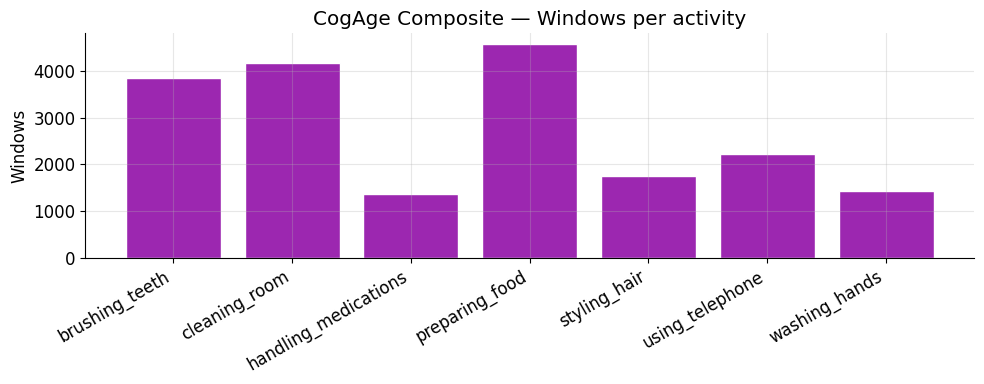

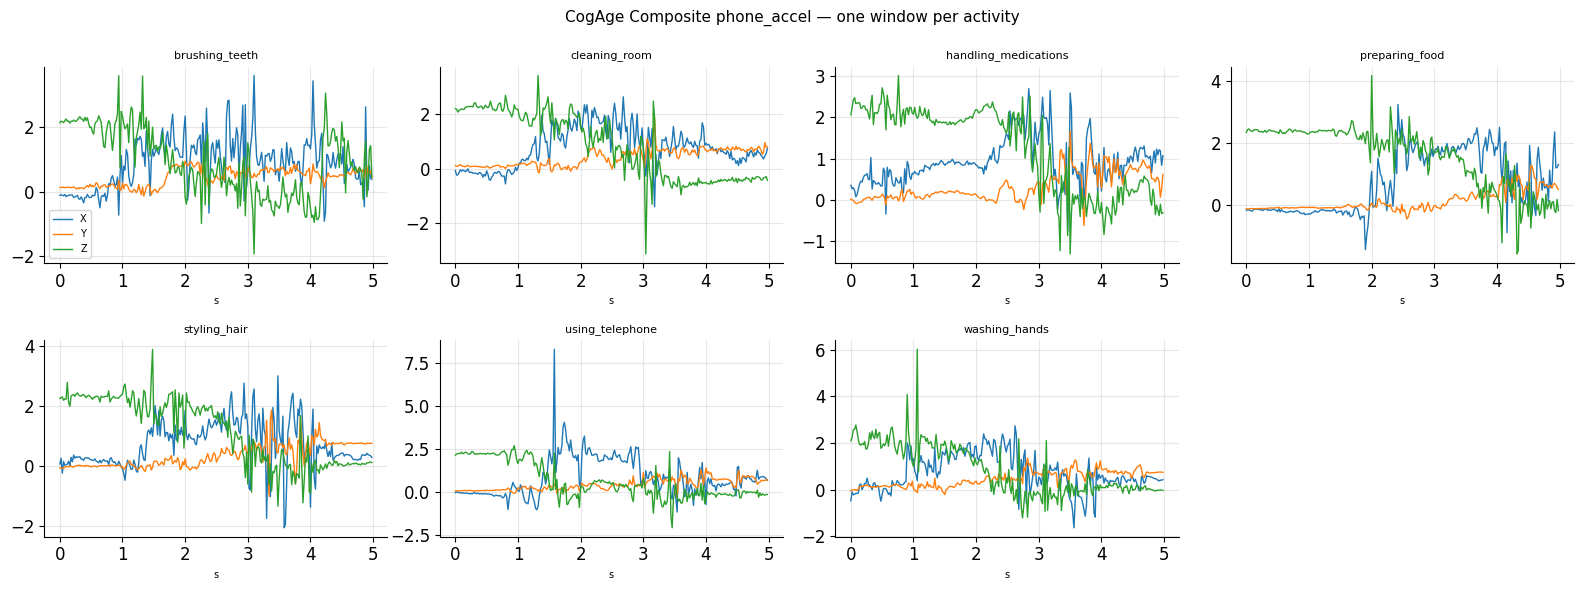

In [ ]:
y_loaded   = loaded['y']
sub_loaded = loaded['subject_ids']

# ─── Plot 1: Windows per activity ─────────────────────────────────────────────
act_names   = [cfg['activity_labels'][i] for i in range(7)]
act_counts  = [(y_loaded == i).sum() for i in range(7)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(7), act_counts, color='#9C27B0', edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(act_names, rotation=30, ha='right')
ax.set_ylabel('Windows')
ax.set_title('CogAge Composite — Windows per activity')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_PATHS['cogage_composite'], 'plot_class_distribution.png'), dpi=120)
plt.show()

# ─── Plot 2: Sample windows from phone_accel for all 7 activities ─────────────
sample_stream = loaded['streams']['phone_accel']
t             = np.arange(WINDOW_SIZE) / TARGET_FREQ

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes_flat  = axes.flatten()
for i, (ax, label) in enumerate(zip(axes_flat, range(7))):
    mask = (y_loaded == label)
    if mask.sum() == 0:
        ax.set_title('No data')
        continue
    win = sample_stream[mask][0]
    ax.plot(t, win[:, 0], linewidth=1, label='X')
    ax.plot(t, win[:, 1], linewidth=1, label='Y')
    ax.plot(t, win[:, 2], linewidth=1, label='Z')
    ax.set_title(cfg['activity_labels'][label], fontsize=8)
    ax.set_xlabel('s', fontsize=7)
    if i == 0:
        ax.legend(fontsize=7)

# Hide the unused 8th subplot
axes_flat[7].set_visible(False)
fig.suptitle('CogAge Composite phone_accel — one window per activity', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_PATHS['cogage_composite'], 'plot_sample_windows.png'), dpi=120)
plt.show()

## Cell 15 — Final Summary

In [ ]:
N = loaded['y'].shape[0]

print('=' * 60)
print('  CogAge COMPOSITE PREPROCESSING COMPLETE')
print('=' * 60)
print(f'  Total windows      : {N:,}')
print(f'  Streams            : {len(STREAM_NAMES)}')
for s in STREAM_NAMES:
    print(f'    {s}')
print(f'  Window shape       : ({WINDOW_SIZE}, 3) @ {TARGET_FREQ}Hz')
print(f'  Classes            : 7 composite activities')
print(f'  Subjects           : {VALID_SUBJECTS}')
print(f'    Train subjects   : {sorted(train_subjects)}')
print(f'    Val subjects     : {sorted(val_subjects)}')
print(f'    Test subjects    : all (from test split folders)')
print(f'  Recordings skipped : {n_recs_skipped}')
print(f'  Saved to           : {PROCESSED_PATHS["cogage_composite"]}')
print('=' * 60)
print()
print('  Files saved:')
for fname in sorted(os.listdir(PROCESSED_PATHS['cogage_composite'])):
    fpath = os.path.join(PROCESSED_PATHS['cogage_composite'], fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'    {fname:<40} {size_mb:.2f} MB')
print()
print('  ✅ Ready — continue with notebook 04 (Humcare)')
print('=' * 60)

  CogAge COMPOSITE PREPROCESSING COMPLETE
  Total windows      : 19,339
  Streams            : 9
    phone_accel
    phone_gravity
    phone_gyro
    phone_linear_accel
    phone_magnetometer
    phone_orientation
    watch_accel
    watch_gyro
    jins_accel
  Window shape       : (250, 3) @ 50Hz
  Classes            : 7 composite activities
  Subjects           : [1, 2, 3, 4, 5, 6]
    Train subjects   : [1, 2, 3, 5, 6]
    Val subjects     : [4]
    Test subjects    : all (from test split folders)
  Recordings skipped : 2
  Saved to           : /content/drive/MyDrive/fsl_har_processed/cogage_composite

  Files saved:
    jins_accel.npy                           58.02 MB
    phone_accel.npy                          58.02 MB
    phone_gravity.npy                        58.02 MB
    phone_gyro.npy                           58.02 MB
    phone_linear_accel.npy                   58.02 MB
    phone_magnetometer.npy                   58.02 MB
    phone_orientation.npy                    58.